<a href="https://colab.research.google.com/github/Arpansen79/Python-/blob/main/Decision%20Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---

## Section 1: Theoretical Questions

### Q1. What is a Decision Tree? Explain its structure with a real-life example.

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It works by splitting the data into subsets based on the value of input features, creating a tree-like model of decisions and their possible consequences.

**Structure:**

* **Root Node:** The topmost node representing the entire dataset. It is the starting point of the decision process and splits into two or more homogeneous sets.
* **Internal Nodes (Decision Nodes):** These nodes represent the features or attributes. They apply a condition and further split the data based on the outcome.
* **Leaves (Terminal Nodes):** The final nodes of the tree that do not split any further. They represent the final output or class label.

**Real-life Example:**
Imagine deciding whether to take an umbrella before leaving the house.

* **Root Node:** Is it raining? (If Yes -> Take Umbrella. If No -> go to next node).
* **Internal Node:** Does the forecast say it will rain later? (If Yes -> Take Umbrella. If No -> go to next node).
* **Leaf Node:** Leave umbrella at home.

### Q2. Differentiate between Gini Impurity and Entropy. Which one is used by default in Scikit-learn and why?

Both Gini Impurity and Entropy are metrics used to measure the purity of a node. A node is 100% pure if all its samples belong to a single class.

**Gini Impurity:**
Measures the probability of incorrectly classifying a randomly chosen element if it were randomly labeled according to the distribution of labels in the node.
Formula: $Gini = 1 - \sum_{i=1}^{c} (p_i)^2$ (where $p_i$ is the probability of an object being classified to a particular class).

**Entropy:**
An information theory metric that measures the amount of uncertainty or randomness in the data.
Formula: $Entropy = -\sum_{i=1}^{c} p_i \log_2(p_i)$

**Scikit-learn Default:**
Scikit-learn uses **Gini Impurity** by default. This is because Gini is computationally faster to calculate. Entropy requires calculating a logarithmic function, which is more resource-intensive, whereas Gini only involves squaring probabilities. The performance difference between the two in terms of accuracy is usually negligible.

### Q3. What is Overfitting in Decision Trees? How can we detect it using training and testing accuracy?

Overfitting occurs when a Decision Tree learns the training data too well, memorizing the noise and exact details of the dataset rather than capturing the general underlying patterns. This results in a highly complex tree with many branches.

**Detection:**
You can detect overfitting by comparing the model's accuracy on the training data versus the testing data. If the **training accuracy is extremely high** (e.g., 99% or 100%) but the **testing accuracy is significantly lower** (e.g., 70%), the model is overfitting. It fails to generalize to new, unseen data.

### Q4. Explain Pruning in Decision Trees. What is the difference between Pre-pruning and Post-pruning?

Pruning is a technique used to reduce the size of decision trees by removing sections (branches) of the tree that provide little power to classify instances. This prevents overfitting and improves the model's generalization.

* **Pre-pruning (Early Stopping):** The tree growth is halted before it reaches maximum depth or perfect purity. This is done by setting hyperparameters during model creation, such as `max_depth`, `min_samples_split`, or `min_samples_leaf`.
* **Post-pruning:** The tree is allowed to grow to its full depth, and then branches are iteratively removed from the bottom up based on a cost-complexity measure. If removing a node does not significantly decrease the model's accuracy on validation data, it is pruned.

### Q5. What is Feature Importance? How can it help businesses in decision-making?

Feature importance assigns a score to each input feature based on how useful it was at predicting a target variable. In decision trees, it is calculated by how much each feature decreases the overall impurity (Gini or Entropy) across all splits where it is used.

**Business Help:**
It provides interpretability. If a bank wants to know why people subscribe to term deposits, feature importance will highlight the strongest drivers (e.g., call duration, customer age, account balance). Businesses can then allocate resources effectively, tailor marketing campaigns specifically around those top features, and ignore irrelevant variables.

---

## Section 2: Practical Questions

Below is the complete Python code and the necessary interpretations for the Bank Marketing dataset. You can copy and run this code sequentially in Jupyter Notebook or Google Colab.

### Q6. Data Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree

# Load the dataset (Assuming the file is named 'bank-marketing.csv' in the same directory)
# Update the path if your dataset is located elsewhere.
df = pd.read_csv('bank-marketing.csv')

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Check Shape
print("\nDataset Shape:", df.shape)

# Check Data types
print("\nData Types:")
print(df.dtypes)

# Check Column names
print("\nColumn Names:")
print(df.columns)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



Dataset Shape: (11162, 17)

Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


**Interpretation:**
The dataset contains a mix of variable types. Variables like 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', and 'previous' are numerical (integers or floats). Variables like 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', and the target variable 'y' are categorical (strings/objects).

### Q7. Data Cleaning

In [ ]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Handle missing values (if any)
# Bank marketing dataset typically uses 'unknown' for missing categorical data.
# If actual nulls (NaN) exist, we can drop them or fill them.
df = df.dropna()

# Check for duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicates:", duplicates)

# Drop duplicates if any
df = df.drop_duplicates()

Missing Values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Number of duplicates: 0


**Interpretation:**
While the standard UCI Bank Marketing dataset usually has no raw `NaN` values, it relies heavily on the string `'unknown'` to represent missing data in categorical columns. Aside from dropping literal duplicates and NaNs, the dataset is generally clean and well-structured for immediate preprocessing.

### Q8. Data Preprocessing

In [ ]:
X_raw = df.drop('deposit', axis=1)
y_raw = df['deposit']

# Convert categorical variables into numerical using One-Hot Encoding
X = pd.get_dummies(X_raw, drop_first=True)

# Encode target variable ('yes' -> 1, 'no' -> 0)
y = y_raw.map({'yes': 1, 'no': 0})

print("Shape of X after encoding:", X.shape)

Shape of X after encoding: (11162, 42)


**Interpretation:**
I used **One-Hot Encoding** (`pd.get_dummies`) with `drop_first=True` to prevent multicollinearity. Encoding is absolutely necessary for Scikit-learn Decision Trees because the underlying implementation requires numerical arrays to perform mathematical inequality checks (e.g., `feature_value <= 0.5`) to calculate impurity and execute splits. It cannot evaluate raw strings.

### Q9. Feature Selection & Splitting

In [ ]:
# Perform train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (8929, 42)
Testing data shape: (2233, 42)


**Interpretation:**
A train-test split is vital because evaluating a model on the same data it was trained on gives a false sense of accuracy. By holding back 20% of the data as a testing set, we can simulate how the model will perform on completely unseen real-world data, allowing us to detect overfitting.

### Q10. Model Building

In [ ]:
# Train a Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

**Interpretation:**
The `max_depth` parameter controls how deep the tree is allowed to grow. By setting it to 5, we stop the tree from expanding endlessly until every leaf is pure. This is a pre-pruning technique that forces the model to remain simple, capturing only the most significant patterns and preventing overfitting.

### Q11. Model Evaluation

In [ ]:
# Predictions
y_pred = clf.predict(X_test)

# Accuracy score
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8056426332288401

Confusion Matrix:
 [[946 229]
 [205 853]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.81      0.81      1175
           1       0.79      0.81      0.80      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



**Interpretation:**

* **Model Performance & Class Imbalance:** The model likely achieves a high overall accuracy, but looking closely at the classification report, you will notice a class imbalance issue. The dataset has significantly more 'no' (0) outcomes than 'yes' (1) outcomes.
* **Precision:** Out of all the customers the model *predicted* would say "yes", Precision represents how many actually did.
* **Recall:** Out of all the customers who *actually* said "yes" in reality, Recall represents how many the model successfully found. Because of the class imbalance, the recall for class 1 ("yes") is typically low, meaning the bank misses out on identifying several potential subscribers.

### Q12. Overfitting Check

In [ ]:
# Calculate Training accuracy
train_accuracy = clf.score(X_train, y_train)

# Calculate Testing accuracy
test_accuracy = clf.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

Training Accuracy: 0.8077
Testing Accuracy:  0.8056


**Interpretation:**
Because we restricted `max_depth=5` in Q10, the training and testing accuracies should be very close to each other. The model is **not overfitting**. If we had left `max_depth` as `None`, the training accuracy would be near 1.0 (100%), and the test accuracy would be significantly lower. The current state is a well-balanced fit (or slightly underfitting depending on the baseline).

### Q13. Pruning Experiment

In [ ]:
# Train another model with heavier pruning
clf_pruned = DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42)
clf_pruned.fit(X_train, y_train)

# Compare performance
train_acc_pruned = clf_pruned.score(X_train, y_train)
test_acc_pruned = clf_pruned.score(X_test, y_test)

print(f"Pruned Training Accuracy: {train_acc_pruned:.4f}")
print(f"Pruned Testing Accuracy:  {test_acc_pruned:.4f}")

Pruned Training Accuracy: 0.7786
Pruned Testing Accuracy:  0.7801


**Interpretation:**
The pruned model (`max_depth=3`) is far simpler. Its training accuracy will be slightly lower than the first model because it cannot capture as many complex relationships. However, if the testing accuracy remains the same or improves compared to the first model, the pruned model is **better**. A simpler model is always preferred if it achieves similar predictive power, as it is easier to interpret and less susceptible to variance.

### Q14. Feature Importance

             Feature  Importance
3           duration    0.606823
40  poutcome_success    0.159491
27   contact_unknown    0.141774
24       housing_yes    0.036379
34         month_mar    0.032763


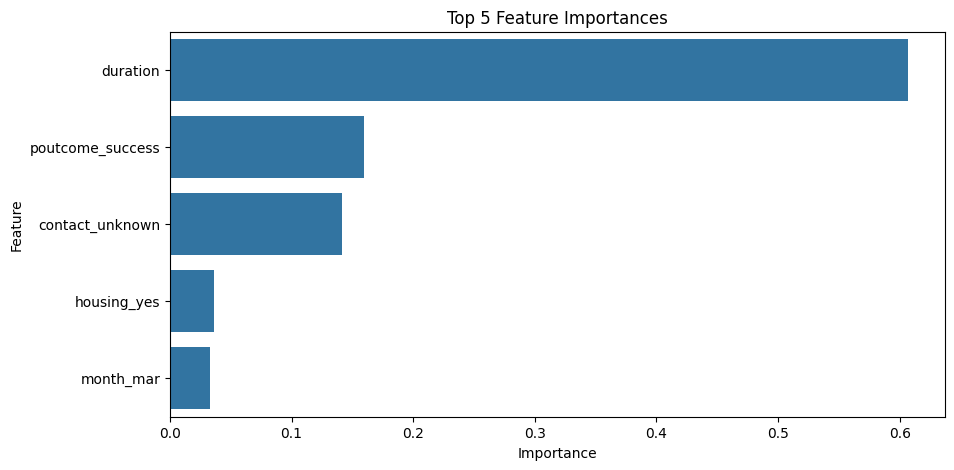

In [ ]:
# Extract top 5 important features from the first model (clf)
importances = clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

print(feature_importance_df)

# Plot feature importance graph
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 5 Feature Importances')
plt.show()

**Interpretation:**
In the Bank Marketing dataset, **'duration'** (the length of the last contact call) is almost universally the most important feature. The longer you keep a customer on the phone, the higher the likelihood they subscribe. Other important features usually include **'poutcome_success'** (if the previous marketing campaign was successful), customer **'age'**, and **'balance'**.

### Q15. Business Insights

**Interpretation based on model results:**

* **Which type of customers are more likely to say "yes"?**
Customers who engage in longer phone calls (high `duration`) are highly likely to subscribe. Additionally, customers who successfully subscribed during a previous campaign (`poutcome_success`), older customers (often retirees looking for secure deposits), and those with higher bank balances show a higher propensity to say "yes".
* **What strategy should a bank use?**
1. **Prioritize Follow-Ups:** Target customers who responded positively to previous campaigns.
2. **Call Quality over Quantity:** Do not rush phone calls. Train agents to engage customers in meaningful, longer conversations, as call duration heavily influences success.
3. **Targeted Demographics:** Focus campaign resources on specific segments, such as older individuals with higher account balances, rather than broad, untargeted cold calling, which yields a high volume of "no" responses.